In [1]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

opj = os.path.join

In [6]:
mask_dir = "/u/bing/sbi_bmode/data/HFI_Mask_GalPlane-apo0_2048_R2.00.fits"

In [8]:
mask = hp.read_map(mask_dir, field=None)

In [20]:
nside = hp.get_nside(mask[3])

# Galactic -> Equatorial (celestial)
rot = hp.Rotator(coord=['G', 'C'])
mask70_eq = rot.rotate_map_pixel(mask[3])

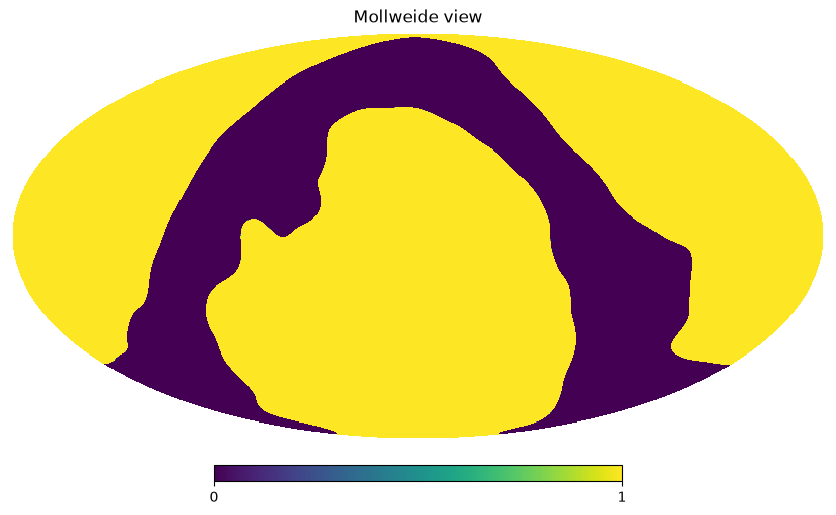

In [21]:
hp.mollview(mask70_eq)

In [24]:
from sbi_bmode import so_utils, sim_utils, script_utils
import yaml

In [25]:
with open('config_transfer.yaml') as f:
    config = yaml.safe_load(f)

data_dict, fixed_params_dict, params_dict, observation_dict, transfer_dict = script_utils.parse_config(config)
true_params = script_utils.get_true_params(params_dict)

In [52]:
specdir = '/u/bing/sbi_bmode/data'
figdir = "/u/bing/sbi_bmode/binh/figures"

sim_obsmat = sim_utils.CMBSimulator(
    specdir,
    data_dict,
    fixed_params_dict,
    observation_dict=observation_dict,
)

Using observation type: obsmat
[obsmat] Reusing ObsMat f090 for all frequencies
[f090 GHz] loading obsmat: sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix.npz
[rank N/A] ObsMat loaded for bands: ['f090']


In [53]:
sim_obsmat.noise_cov_ell[:] = 0.0

In [54]:
out_obsmat = sim_obsmat.draw_data(
    **true_params,
    seed=0,
    return_maps=True,
)

[obsmat] split 0, freq f090


In [55]:
obs_map = out_obsmat['obs_map'][0, 0, 0]   # shape (npix,)
nside_obs = hp.get_nside(obs_map)

footprint_mask = (obs_map == 0).astype(float)

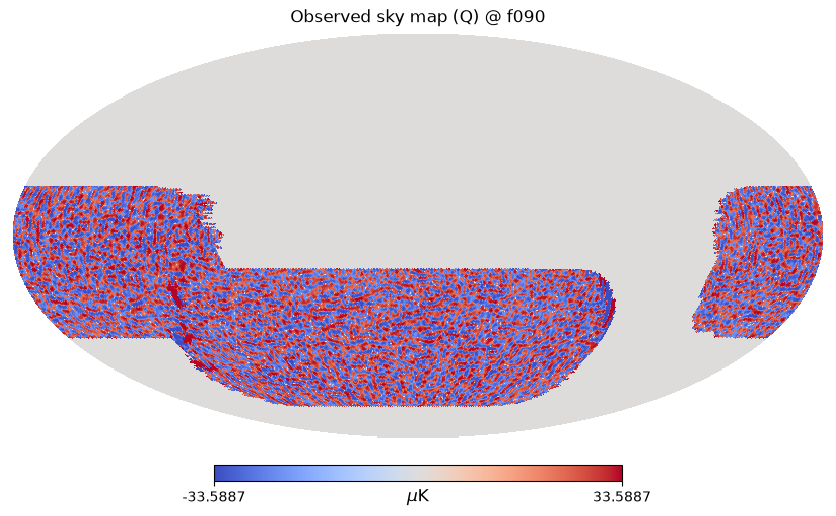

In [56]:
hp.mollview(
    out_obsmat['obs_map'][0,0,0],
    min=-np.nanmax(np.abs(out_obsmat['obs_map'][0,0,0])),
    max= np.nanmax(np.abs(out_obsmat['obs_map'][0,0,0])),
    cmap="coolwarm",
    unit=r"$\mu\mathrm{K}$",
    norm="hist",
    title="Observed sky map (Q) @ f090"
)

In [57]:
obs_map = out_obsmat['obs_map'][0, 0, 0]   # shape (196608,) -> nside=128
nside_obs = hp.get_nside(obs_map)          # 128
footprint_mask = (obs_map != 0).astype(float)

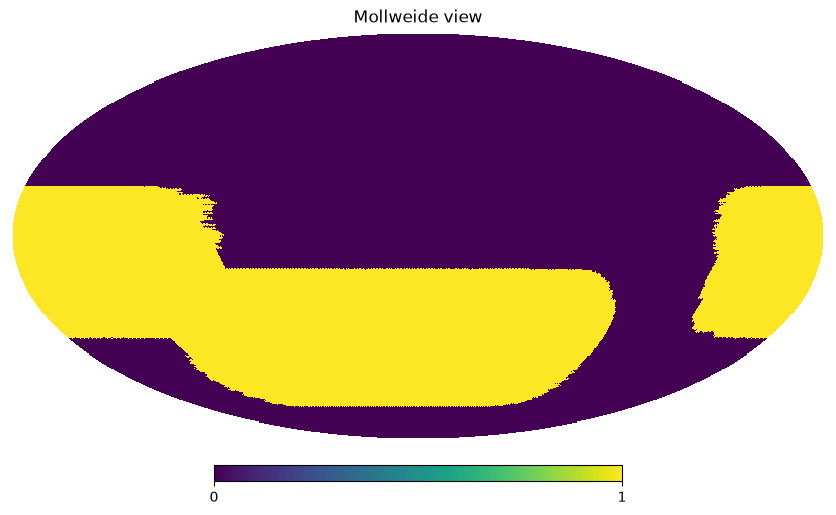

In [58]:
hp.mollview(footprint_mask)

In [59]:
rot = hp.Rotator(coord=['G', 'C'])          # match to your Equatorial obs_map
mask70_eq = rot.rotate_map_pixel(mask[3])

if hp.get_nside(mask70_eq) != nside_obs:
    # ud_grade on a binary mask before thresholding avoids fuzzy edges creeping in
    mask70_eq = hp.ud_grade(mask70_eq, nside_out=nside_obs)
    mask70_eq = (mask70_eq > 0.5).astype(float)  # re-binarize after downgrade

# --- 3. Combine ---
combined_mask = footprint_mask * mask70_eq

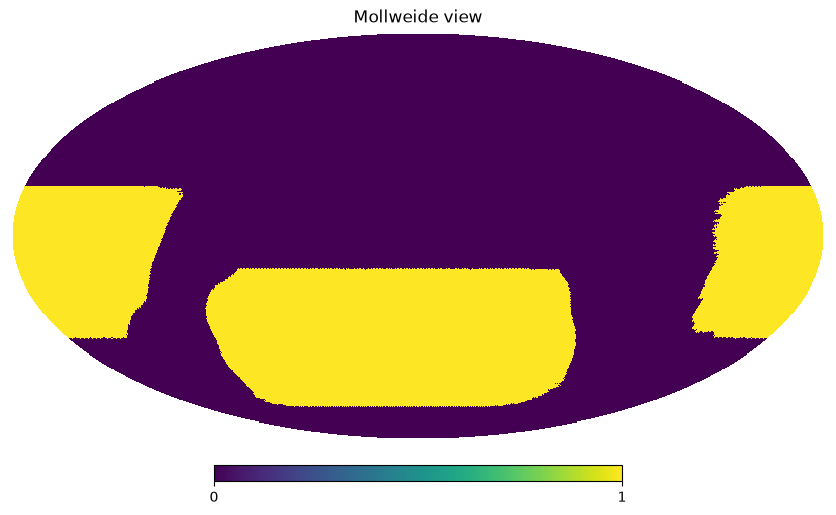

In [60]:
hp.mollview(combined_mask)

f_sky (binary combined) : 0.3154
f_sky (apodized)        : 0.2943


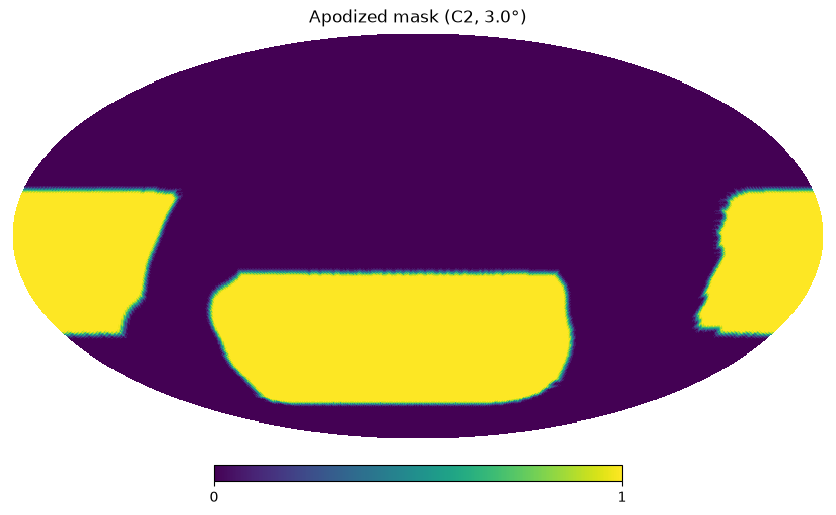

In [61]:
import pymaster as nmt

apod_scale = 3.0
apod_type = "C2"

mask_apod = nmt.mask_apodization(combined_mask, apod_scale, apod_type)

print(f"f_sky (binary combined) : {combined_mask.mean():.4f}")
print(f"f_sky (apodized)        : {mask_apod.mean():.4f}")

hp.mollview(mask_apod, title=f"Apodized mask (C2, {apod_scale}°)")

In [63]:
apod_mask_file = opj(specdir, "obsmat_planck70_apod_C2_3deg.fits")
hp.write_map(apod_mask_file, mask_apod, dtype=np.float32, overwrite=True)

In [64]:
sim_obsmat = sim_utils.CMBSimulator(
    specdir,
    data_dict,
    fixed_params_dict,
    observation_dict=observation_dict,
    mask_file=apod_mask_file,   # the binary combined mask you just saved
)

Using observation type: obsmat
[obsmat] Reusing ObsMat f090 for all frequencies
[f090 GHz] loading obsmat: sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix.npz
[rank N/A] ObsMat loaded for bands: ['f090']
Loading mask from /u/bing/sbi_bmode/data/obsmat_planck70_apod_C2_3deg.fits


In [65]:
out_obsmat = sim_obsmat.draw_data(
    **true_params,
    seed=0,
    return_maps=True,
)

[obsmat] split 0, freq f090


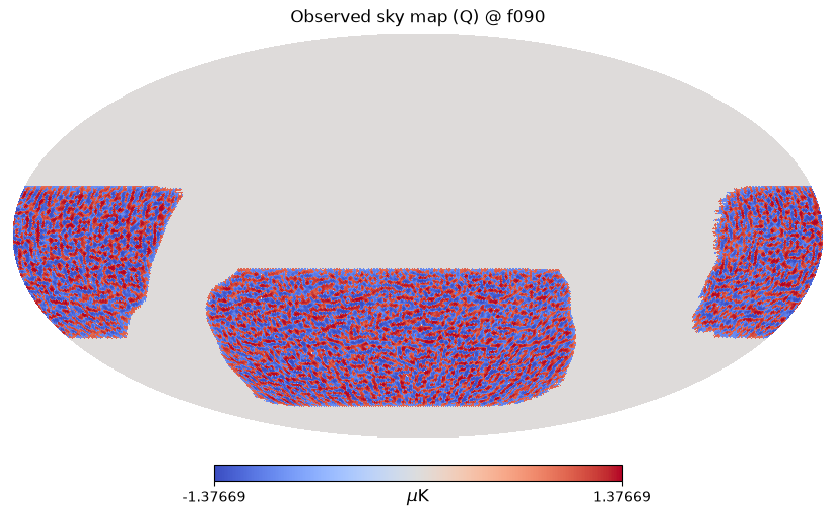

In [66]:
hp.mollview(
    out_obsmat['obs_map'][0,0,0],
    min=-np.nanmax(np.abs(out_obsmat['obs_map'][0,0,0])),
    max= np.nanmax(np.abs(out_obsmat['obs_map'][0,0,0])),
    cmap="coolwarm",
    unit=r"$\mu\mathrm{K}$",
    norm="hist",
    title="Observed sky map (Q) @ f090"
)